## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Linear Regression</p>

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
df = pd.read_csv("../data/processed/auto_scout_final.csv")

In [4]:
df.shape

(15915, 140)

# Import Required Libraries

In [5]:
# Import libraries for data splitting, preprocessing,
# model building, and evaluation.

# Splits the dataset into training and testing sets.
from sklearn.model_selection import train_test_split 

# Standardizes numerical features to improve model performance.
from sklearn.preprocessing import StandardScaler

# Builds the linear regression model.
from sklearn.linear_model import LinearRegression

# Evaluation metrics are used to measure prediction accuracy.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define Features and Target Variable

In [6]:
# Separate the independent variables (features)
# from the dependent variable (target).

X = df.drop('price', axis=1) # X contains all predictor variables.
y = df['price'] # y is the target variable (price) that the model will predict.

# Split the Dataset

In [7]:
# Training set (80%) is used to train the model.
# Testing set (20%) is used to evaluate the model.
# random_state=42 ensures the split is reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the Features 

In [9]:
# Scaling prevents features with larger values from dominating the model.
# The scaler is fitted only on the training data to avoid data leakage.
# The same transformation is then applied to the test data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Linear Regression Model

In [11]:
# Create an instance of the Linear Regression model.
# This initializes the Linear Regression algorithm with default parameters.

lr = LinearRegression()

# Train the Model

In [13]:
# Train the model using the training dataset.
# The model learns the relationship between the input features and the target variable.

lr.fit(X_train_scaled, y_train)

LinearRegression()

# Make Predictions

In [15]:
# Predict the prices for the testing dataset.
# The trained model estimates the price for each observation in the test set.

y_pred = lr.predict(X_test_scaled)

# Evaluate the Model

In [16]:
# Calculate evaluation metrics to measure
# the model's prediction performance.

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 125949656335.31
MSE  : 50492933235455268157915136.00
RMSE : 7105837968561.85
R²   : -935616026589212160.0000


# Note:

MAE (Mean Absolute Error): Average absolute difference between actual and predicted prices. Lower is better.

MSE (Mean Squared Error): Average squared prediction error. Penalizes larger errors more heavily.

RMSE (Root Mean Squared Error): Error expressed in the same units as the target variable (price). Lower is better.

R² Score (Coefficient of Determination): Measures how much of the variation in price is explained by the model. Values closer to 1 indicate a better fit.

# Compare Actual and Predicted Values

In [18]:
# Create a table to compare actual prices
# with the predicted prices.
# This table helps you inspect how close the model's predictions are to the actual prices.

results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
12887,26379,25520.873764
8140,18990,18319.561407
6835,12490,11945.862723
15439,32975,34444.443137
1213,15888,14949.156203
13187,15480,14665.890313
1034,20500,21574.022268
2864,16760,16261.112432
7061,18990,17381.621142
14983,27000,23832.144748


--> Most predictions are close to the actual prices.

--> The model captures the overall relationship between the features and the target.

--> A few observations have larger prediction errors, which is expected in a baseline linear regression model.

# Visualize the Results

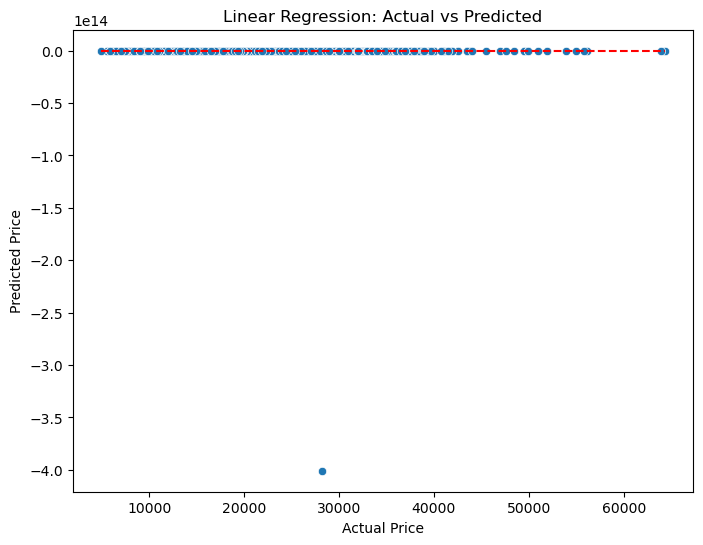

In [19]:
# Plot actual prices against predicted prices.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

# Note:

Each point represents one observation.

The red dashed line represents perfect predictions (Actual = Predicted).

Points closer to the line indicate more accurate predictions, while points farther away represent larger prediction errors.

In [20]:
print(y_pred.min())
print(y_pred.max())

-400897750637046.44
49392.53862000597


The output confirms there is one extremely abnormal prediction:

In [25]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.sort_values("Predicted").head()

,Actual,Predicted
2614,28200,-4.008978e+14
13638,7200,7.275313e+02
8762,6890,1.517913e+03
13741,6500,1.600257e+03
13636,7200,1.988025e+03


### The first row is clearly invalid. The other predictions are low but still plausible. The extreme negative value is what's distorting your scatter plot.

In [26]:
# Inspect the problematic observation
bad_index = results["Predicted"].idxmin()

X_test.loc[[bad_index]]

,km,prev_owner,hp,inspection_new,warranty,nr_of_doors,nr_of_seats,displacement,cylinders,weight,...,'LED Headlights','Lane departure warning system','Passenger-side airbag','Power steering','Rear airbag','Side airbag','Tire pressure monitoring system','Traction control','Traffic sign recognition','Xenon headlights'
2614,26166.0,1.0,85.0,0,0.0,5.0,5.0,1598.0,4.0,1487.0,...,0,1,1,1,0,1,1,1,0,0


In [27]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef["Absolute"] = coef["Coefficient"].abs()

coef.sort_values("Absolute", ascending=False).head(20)

,Feature,Coefficient,Absolute
15,make_model_Audi A2,-4.008978e+14,4.008978e+14
2,hp,2.634309e+03,2.634309e+03
20,make_model_Renault Clio,-1.767819e+03,1.767819e+03
18,make_model_Opel Corsa,-1.765669e+03,1.765669e+03
13,year,1.675821e+03,1.675821e+03
0,km,-1.479021e+03,1.479021e+03
17,make_model_Opel Astra,-1.396907e+03,1.396907e+03
36,new_used_Used,-1.327942e+03,1.327942e+03
22,make_model_Renault Espace,9.748763e+02,9.748763e+02
33,new_used_Employee's car,-7.515364e+02,7.515364e+02


In [28]:
df[df['make_model_Audi A2'] == 1].shape

(1, 140)

In [29]:
pd.get_dummies(df, drop_first=True)

,price,km,prev_owner,hp,inspection_new,warranty,nr_of_doors,nr_of_seats,displacement,cylinders,...,'LED Headlights','Lane departure warning system','Passenger-side airbag','Power steering','Rear airbag','Side airbag','Tire pressure monitoring system','Traction control','Traffic sign recognition','Xenon headlights'
0,15770,56013.0,2.0,66.0,1,0.0,5.0,5.0,1422.0,3.0,...,0,0,1,1,0,1,1,1,0,1
1,14500,80000.0,1.0,141.0,0,0.0,3.0,4.0,1798.0,4.0,...,0,0,1,1,0,1,1,1,0,1
2,14640,83450.0,1.0,85.0,0,0.0,5.0,4.0,1598.0,4.0,...,0,0,1,1,0,1,1,1,0,0
3,14500,73000.0,1.0,66.0,0,0.0,3.0,4.0,1422.0,3.0,...,0,0,1,1,0,1,1,0,0,0
4,16790,16200.0,1.0,66.0,1,0.0,5.0,5.0,1422.0,3.0,...,0,0,1,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,39950,15.0,0.0,147.0,0,24.0,5.0,5.0,1997.0,4.0,...,1,1,1,1,1,1,1,1,1,0
15911,39885,9900.0,1.0,165.0,0,0.0,5.0,5.0,1798.0,4.0,...,1,1,1,1,0,1,1,1,1,0
15912,39875,15.0,0.0,146.0,1,0.0,5.0,7.0,1997.0,4.0,...,1,1,1,1,0,1,0,1,1,0
15913,39700,10.0,0.0,147.0,0,0.0,5.0,7.0,1997.0,4.0,...,1,0,1,1,0,1,1,0,1,0


In [30]:
df['make_model_Audi A2'].value_counts()

0    15914
1        1
Name: make_model_Audi A2, dtype: int64

In [31]:
print(df['make_model_Audi A2'].sum())

1


## After removing the rare category (or rare dummy variables), let's verify that the model behaves normally.

In [32]:
# Remove the dummy variable that appears only once
X = X.drop(columns=['make_model_Audi A2'])

In [35]:
# Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
# Scale the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Train the model again
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [40]:
# Predict
y_pred = lr.predict(X_test_scaled)

In [41]:
# Check the prediction range
print("Minimum prediction:", y_pred.min())
print("Maximum prediction:", y_pred.max())

Minimum prediction: 727.4948055675995
Maximum prediction: 49391.35035283816


In [43]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1715.37
RMSE: 2407.54
R²  : 0.8926


In [45]:
# Verify the coefficients
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef["Absolute"] = coef["Coefficient"].abs()

coef.sort_values("Absolute", ascending=False).head(10)

,Feature,Coefficient,Absolute
2,hp,2634.206636,2634.206636
19,make_model_Renault Clio,-1767.845662,1767.845662
17,make_model_Opel Corsa,-1765.604563,1765.604563
13,year,1675.823834,1675.823834
0,km,-1479.026020,1479.026020
16,make_model_Opel Astra,-1396.831014,1396.831014
35,new_used_Used,-1327.987738,1327.987738
21,make_model_Renault Espace,974.918418,974.918418
32,new_used_Employee's car,-751.465922,751.465922
34,new_used_Pre-registered,-656.999558,656.999558


### The Linear Regression model was used as the baseline regression model for predicting car prices. After removing a rare categorical feature that caused numerical instability, the model achieved an R² score of 0.8926, indicating that it explains approximately 89% of the variance in the target variable. The MAE (1,715) and RMSE (2,408) show that the model provides reasonably accurate predictions. These results demonstrate that Linear Regression is an effective baseline model for this dataset